# 1 month salt budget test for ACCESS control, shelf only

NOTEBOOK IS WIP. CONVERTING OLD CODE.

In [1]:
import glob
import dask.distributed as dsk
import matplotlib.pyplot as plt
import xarray as xr
import cf_xarray as cfxr
import numpy as np
import xesmf as xe
from matplotlib.colors import to_rgba

import cmocean as cm
import cartopy.crs as ccrs

import cartopy.feature as cft
import matplotlib.path as mpath

import warnings # ignore these warnings
warnings.filterwarnings("ignore", category = FutureWarning)
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = RuntimeWarning)

In [2]:
lat_slice = slice(-79,-59)

# Importing data
paths_2_C = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/01deg_jra55v13_ryf9091_21mbath_copy-15025726/output040/ocean/ocean.nc'))
paths_1_C = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/01deg_jra55v13_ryf9091_21mbath_copy-15025726/output040/ocean/ocean_month.nc'))

paths_2_M = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/access-ssp126-sofia-expt-c085baf0/output040/ocean/ocean.nc'))
paths_1_M = np.sort(glob.glob('/scratch/x77/kc5856/access-om2/archive/access-ssp126-sofia-expt-c085baf0/output040/ocean/ocean_month.nc'))

In [3]:
# Time variant variables
def preprocess_1(ds):
    ds = ds[['pme_river','runoff','evap','pme_correct']].sel(yt_ocean=lat_slice)
    return ds

def preprocess_2(ds):
    ds = ds[['salt','salt_advection','salt_submeso','salt_tendency','salt_vdiffuse_impl','salt_nonlocal_KPP','salt_rivermix','salt_eta_smooth']].sel(yt_ocean=lat_slice)
    return ds

data_1_C = xr.open_mfdataset(paths_1_C, preprocess = preprocess_1, chunks = 'auto')
data_2_C = xr.open_mfdataset(paths_2_C, preprocess = preprocess_2, chunks = 'auto')

data_1_M = xr.open_mfdataset(paths_1_M, preprocess = preprocess_1, chunks = 'auto')
data_2_M = xr.open_mfdataset(paths_2_M, preprocess = preprocess_2, chunks = 'auto')

In [4]:
# Shelf mask

def shelf_mask_isobath(var, model_dict):

    paths = {
             "mom5": "/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz",
             "mom6_01": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_01deg.nc",
            "mom6_005": "/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_005deg.nc"
             }

    var = var.cf.sel({'latitude': slice(-90, -59)})

    if paths[model_dict][-3:] == '.nc':
        shelf_mask = xr.open_dataset(paths[model_dict])['contour_masked_above']
    else:
        contour_file = np.load(paths[model_dict])
        shelf_mask = xr.DataArray(contour_file['contour_masked_above'],
                                  coords = var.coords, 
                                  dims = var.dims,
                                  name = 'contour_masked_above')
    
    shelf_mask = xr.where(shelf_mask == 0, 1, 0)
    masked_var = var * shelf_mask
    
    return masked_var, shelf_mask

In [5]:
depth = xr.open_dataset('/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output012/ocean/ocean_grid.nc')['ht']
land_mask = (0 * depth).fillna(1)
land = xr.where(np.isnan(depth.rename('land_1')), 1, np.nan)
depth_shelf, shelf_mask = shelf_mask_isobath(depth, 'mom5')

In [6]:
# --- Control (_C) diagnostics ---
tendency_C          = data_2_C.salt_tendency
advection_C         = data_2_C.salt_advection
submeso_C           = data_2_C.salt_submeso
vert_diff_surface_C  = data_2_C.salt_vdiffuse_impl
nonlocal_KPP_C      = data_2_C.salt_nonlocal_KPP
river_mix_C         = data_2_C.salt_rivermix
eta_smooth_C        = data_2_C.salt_eta_smooth

# --- Melt (_M) diagnostics ---
tendency_M          = data_2_M.salt_tendency
advection_M         = data_2_M.salt_advection
submeso_M           = data_2_M.salt_submeso
vert_diff_surface_M  = data_2_M.salt_vdiffuse_impl
nonlocal_KPP_M      = data_2_M.salt_nonlocal_KPP
river_mix_M         = data_2_M.salt_rivermix
eta_smooth_M        = data_2_M.salt_eta_smooth

In [7]:
# Getting SSS
SSS_C = data_2_C.salt.isel(time=0,st_ocean=0)
SSS_M = data_2_M.salt.isel(time=0,st_ocean=0)

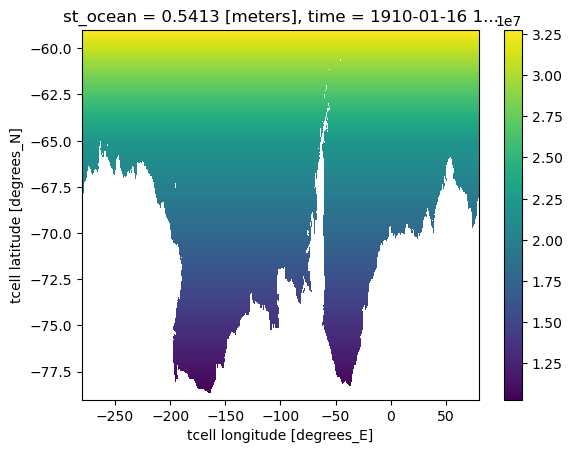

In [8]:
# Loading area
area = xr.open_dataset('/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output012/ocean/ocean_grid.nc')['area_t']
var = data_2_C.salt.isel(time=0,st_ocean=0)
area_corr = area*(var*0 +1)
area_corr.plot()

In [9]:
# Mapping from your base names to dataset variable names
var_map = {
    "tendency": "salt_tendency",
    "advection": "salt_advection",
    "submeso": "salt_submeso",
    "vert_diff_surface": "salt_vdiffuse_impl",
    "nonlocal_KPP": "salt_nonlocal_KPP",
    "river_mix": "salt_rivermix",
    "eta_smooth": "salt_eta_smooth"
}

# Dictionaries to hold processed FWF results
results_C = {}
results_M = {}

zdim = 'st_ocean'

In [10]:
# Doing the depth integration over shelf only 

for var_base, var_dsname in var_map.items():
    for suffix, data, SSS, res_dict in zip(
        ["_C", "_M"], [data_2_C, data_2_M], [SSS_C, SSS_M], [results_C, results_M]
    ):
        # Access the correct variable from the dataset
        var_data = data[var_dsname]

        # Convert to freshwater flux units
        var_FWF = -var_data * 1000 / SSS

        # Apply shelf mask and handle depth integration
        var_plot = var_FWF.isel(time=0).where(shelf_mask == 1)

        if var_base != "eta_smooth":
            # Sum over z only for variables that have a vertical dimension
            var_plot = var_plot.sum(zdim)

        # Squeeze and compute
        var_plot = var_plot.squeeze().compute()

        # Area-weighted average
        shelf_area = area_corr.where(shelf_mask == 1).sum(['xt_ocean', 'yt_ocean'])
        var_ave = (area_corr * var_plot).sum(['xt_ocean', 'yt_ocean']) / shelf_area
        var_ave = var_ave.load()

        # Store in dictionary
        res_dict[var_base] = var_ave

In [14]:
# Control (_C) averages
tendency_ave_C         = results_C["tendency"]
advection_ave_C        = results_C["advection"]
submeso_ave_C          = results_C["submeso"]
vert_diff_surface_ave_C = results_C["vert_diff_surface"]
nonlocal_KPP_ave_C     = results_C["nonlocal_KPP"]
river_mix_ave_C        = results_C["river_mix"]
eta_smooth_ave_C       = results_C["eta_smooth"]

# Melt (_M) averages
tendency_ave_M         = results_M["tendency"]
advection_ave_M        = results_M["advection"]
submeso_ave_M          = results_M["submeso"]
vert_diff_surface_ave_M = results_M["vert_diff_surface"]
nonlocal_KPP_ave_M     = results_M["nonlocal_KPP"]
river_mix_ave_M        = results_M["river_mix"]
eta_smooth_ave_M       = results_M["eta_smooth"]

**On average, how much salt per square metre is being added/removed from the shelf (full-depth integrated), due to...**

In [15]:
print("**Control diagnostics**",
      "\ntendency =", tendency_ave_C.values,
      "\nadvection =", advection_ave_C.values,
      "\nsubmeso =", submeso_ave_C.values,
      "\nvertical diffusion (surface) =", vert_diff_surface_ave_C.values,
      "\nnonlocal KPP =", nonlocal_KPP_ave_C.values,
      "\nriver mixing =", river_mix_ave_C.values,
      "\neta smoothing =", eta_smooth_ave_C.values
     )

print("\n**Melt diagnostics**",
      "\ntendency =", tendency_ave_M.values,
      "\nadvection =", advection_ave_M.values,
      "\nsubmeso =", submeso_ave_M.values,
      "\nvertical diffusion (surface) =", vert_diff_surface_ave_M.values,
      "\nnonlocal KPP =", nonlocal_KPP_ave_M.values,
      "\nriver mixing =", river_mix_ave_M.values,
      "\neta smoothing =", eta_smooth_ave_M.values
     )

**Control diagnostics** 
tendency = 0.00015764633 
advection = 0.00017707316 
submeso = -4.1994266e-09 
vertical diffusion (surface) = -1.9839197e-05 
nonlocal KPP = 1.3577365e-16 
river mixing = -4.531796e-14 
eta smoothing = 4.1654224e-07

**Melt diagnostics** 
tendency = 0.00016265266 
advection = 0.00017535644 
submeso = -3.630665e-09 
vertical diffusion (surface) = -1.3114403e-05 
nonlocal KPP = -4.3171337e-16 
river mixing = -1.548296e-14 
eta smoothing = 4.1426313e-07


In [16]:
# Checking closure for your full variable set

print("**Control (_C)**")
print("LHS =", tendency_ave_C.values,
      "\nRHS =", (advection_ave_C + submeso_ave_C + vert_diff_surface_ave_C + 
                  nonlocal_KPP_ave_C + river_mix_ave_C + eta_smooth_ave_C).values)

print("\n**Melt (_M)**")
print("LHS =", tendency_ave_M.values,
      "\nRHS =", (advection_ave_M + submeso_ave_M + vert_diff_surface_ave_M + 
                  nonlocal_KPP_ave_M + river_mix_ave_M + eta_smooth_ave_M).values)

**Control (_C)**
LHS = 0.00015764633 
RHS = 0.00015764631

**Melt (_M)**
LHS = 0.00016265266 
RHS = 0.00016265268


### Plotting with freshwater flux terms

In [17]:
data = np.load("/g/data/x77/kc5856/analysis/access-panan-comparison/freshwater_budget_values_access.npz")

# Control terms
pme_river_C     = data["pme_river_C"]
pme_net_C       = data["pme_net_C"]
river_C         = data["river_C"]
wfimelt_C       = data["wfimelt_C"]
wfiform_C       = data["wfiform_C"]
melt_C          = data["melt_C"]
pme_correct_C   = data["pme_correct_C"]
budget_C        = data["budget_C"]

# Melt terms
pme_river_M     = data["pme_river_M"]
pme_net_M       = data["pme_net_M"]
river_M         = data["river_M"]
wfimelt_M       = data["wfimelt_M"]
wfiform_M       = data["wfiform_M"]
melt_M          = data["melt_M"]
pme_correct_M   = data["pme_correct_M"]
budget_M        = data["budget_M"]

In [18]:
# Salt flux variables
salt_vars = [
    ("tendency", tendency_ave_C, tendency_ave_M),
    ("advection", advection_ave_C, advection_ave_M),
    ("submeso", submeso_ave_C, submeso_ave_M),
    ("vert_diff_surface", vert_diff_surface_ave_C, vert_diff_surface_ave_M),
    ("nonlocal_KPP", nonlocal_KPP_ave_C, nonlocal_KPP_ave_M),
    ("river_mix", river_mix_ave_C, river_mix_ave_M),
    ("eta_smooth", eta_smooth_ave_C, eta_smooth_ave_M)
]

# Freshwater budget variables
fwf_vars = [
    ("pme_river", pme_river_C, pme_river_M),
    ("pme_net", pme_net_C, pme_net_M),
    ("river", river_C, river_M),
    ("wfimelt", wfimelt_C, wfimelt_M),
    ("wfiform", wfiform_C, wfiform_M),
    ("melt", melt_C, melt_M),
    ("pme_correct", pme_correct_C, pme_correct_M),
    ("budget", budget_C, budget_M)
]

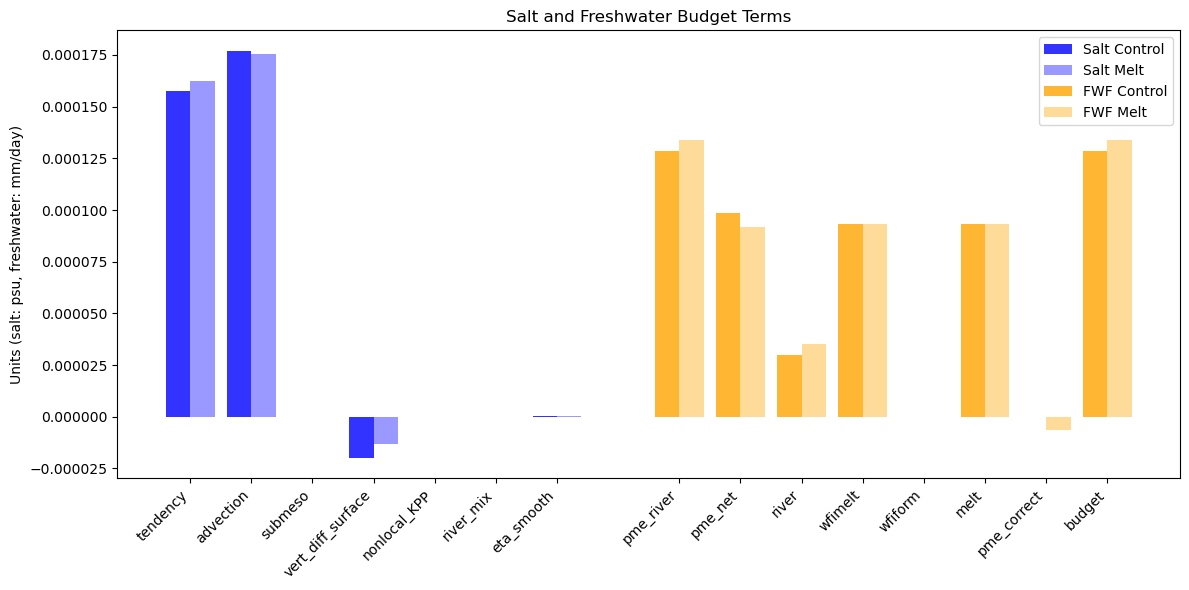

In [19]:
# Set up plot
fig, ax = plt.subplots(figsize=(12,6))

# X positions for plotting
x_salt = np.arange(len(salt_vars))
x_fwf  = np.arange(len(fwf_vars)) + len(salt_vars) + 1  # leave 1 space

# --- Plot Salt variables ---
for i, (name, val_C, val_M) in enumerate(salt_vars):
    ax.bar(i-0.2, val_C.values, width=0.4, color='blue', alpha=0.8, label='Salt Control' if i==0 else "")
    ax.bar(i+0.2, val_M.values, width=0.4, color='blue', alpha=0.4, label='Salt Melt' if i==0 else "")

# --- Plot Freshwater variables ---
for i, (name, val_C, val_M) in enumerate(fwf_vars):
    xi = i + len(salt_vars) + 1
    ax.bar(xi-0.2, val_C, width=0.4, color='orange', alpha=0.8, label='FWF Control' if i==0 else "")
    ax.bar(xi+0.2, val_M, width=0.4, color='orange', alpha=0.4, label='FWF Melt' if i==0 else "")

# Labels
ax.set_xticks(list(x_salt) + list(x_fwf))
ax.set_xticklabels([name for name,_ ,_ in salt_vars] + [name for name,_,_ in fwf_vars], rotation=45, ha='right')
ax.set_ylabel("Units (salt: psu, freshwater: mm/day)")
ax.set_title("Salt and Freshwater Budget Terms")

# Legend
ax.legend()

# Layout
plt.tight_layout()
plt.show()

#### Checking that the restoring accounts for the vert_diff_surface difference

In [22]:
print("melt experiment restoring =", pme_correct_M,
      "\nvert_diff_surface anomaly =", (vert_diff_surface_ave_M - vert_diff_surface_ave_C).values)

melt experiment restoring = -6.628675e-06 
vert_diff_surface anomaly = 6.724794e-06


So this difference looks like it balances! Aka, the difference in the salt flux surface forcing is due to the fact that the restoring is input as a freshwater flux in the meltwater experiment, but as a salt flux in the control experiment.   
Minor difference in values could be attributed to imperfect nature of the salt flux to freshwater flux conversion using sea surface salinity.